# 🌍 Deforestation Detection 


**🔹 This notebook trains a CNN model using Transfer Learning to classify satellite images as 'Forest' or 'Deforested'.**

**🛠 Steps:**
1. 📥 Load dataset (Kaggle or local images).
2. 🖼️ Preprocess images (resize, normalize, augment).
3. 🧠 Train CNN using Transfer Learning (VGG16).
4. 📊 Evaluate model accuracy.
5. 🚀 Save model for later use.


In [1]:
# ✅ Step 1: Install Dependencies
!pip install tensorflow keras numpy pandas matplotlib pillow kaggle

## 📥 Load and Preprocess Dataset

In [10]:
import pandas as pd
df = pd.read_csv("/home/fiona/Desktop/tuts/school_project/kaggle_data/dataset/covtype.csv")
print(df.head())  # View first few rows


   2596   51   3  258    0   510  221  232  148  6279  ...  0.34  0.35  0.36  \
0  2590   56   2  212   -6   390  220  235  151  6225  ...     0     0     0   
1  2804  139   9  268   65  3180  234  238  135  6121  ...     0     0     0   
2  2785  155  18  242  118  3090  238  238  122  6211  ...     0     0     0   
3  2595   45   2  153   -1   391  220  234  150  6172  ...     0     0     0   
4  2579  132   6  300  -15    67  230  237  140  6031  ...     0     0     0   

   0.37  0.38  0.39  0.40  0.41  0.42  5  
0     0     0     0     0     0     0  5  
1     0     0     0     0     0     0  2  
2     0     0     0     0     0     0  2  
3     0     0     0     0     0     0  5  
4     0     0     0     0     0     0  2  

[5 rows x 55 columns]


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/home/fiona/Desktop/tuts/school_project/kaggle_data/dataset/covtype.csv")

# Separate features & labels
X = df.iloc[:, :-1].values  # All columns except the last one
y = df.iloc[:, -1].values   # The last column is the target (forest cover type)

# Convert labels to binary (Deforested vs. Non-Deforested)
# Example: Assuming class '2' represents deforested land, change this based on your dataset documentation.
y_binary = (y == 2).astype(int)  # Convert to 1 if deforested, else 0

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 96.25%
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     59439
           1       0.95      0.97      0.96     56764

    accuracy                           0.96    116203
   macro avg       0.96      0.96      0.96    116203
weighted avg       0.96      0.96      0.96    116203



In [18]:
# Get feature importances
feature_importances = model.feature_importances_
feature_names = df.columns[:-1]  # Get column names except the last one

# Create a DataFrame for better readability
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importances}
)

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Print the top 10 most important features
print("Top 10 Most Important Features in Deforestation Prediction:")
print(feature_importance_df.head(10))


Top 10 Most Important Features in Deforestation Prediction:
  Feature  Importance
0    2596    0.241088
5     510    0.124490
9    6279    0.116272
3     258    0.061705
4       0    0.058867
1      51    0.048848
7     232    0.043951
8     148    0.041492
6     221    0.040326
2       3    0.032175


In [19]:
import joblib

# Save the trained model to a file
joblib.dump(model, "deforestation_model.pkl")

print("Model saved successfully!")


Model saved successfully!


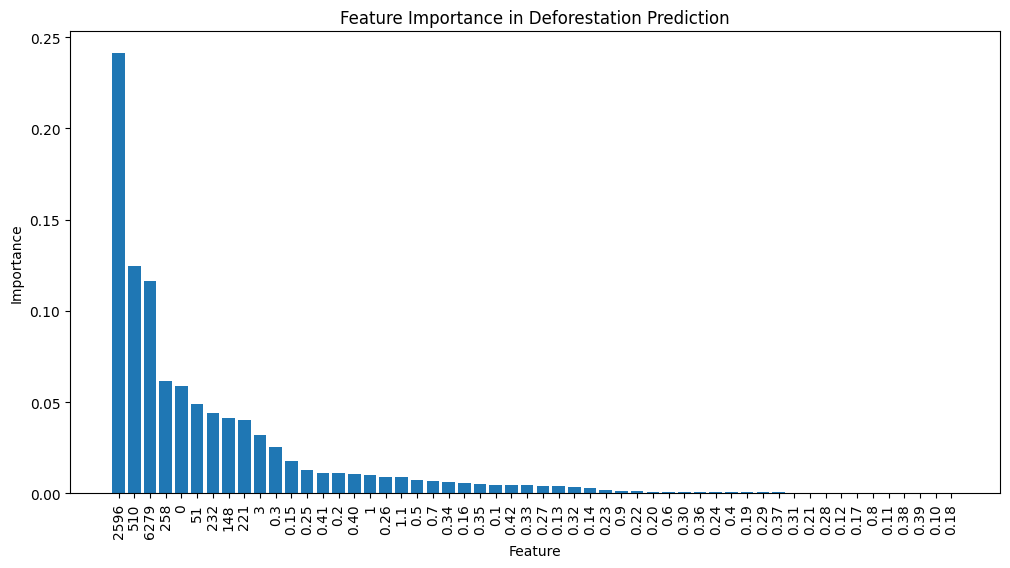

In [17]:
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
feature_names = df.columns[:-1]

# Sort feature importances
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(sorted_features)), sorted_importances, align="center")
plt.xticks(range(len(sorted_features)), sorted_features, rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Deforestation Prediction")
plt.show()